# Praktikum Pra-Pemrosesan Data
**Dataset:** House Prices - Advanced Regression Techniques (train.csv)
**Nama:** Patrik
**Mata Kuliah:** Data Mining / Pra-Pemrosesan Data

## Tujuan Praktikum
1. Memahami dan menerapkan langkah-langkah praproses data seperti pembersihan data.
2. Meningkatkan kualitas data melalui penanganan nilai yang hilang dan data yang tidak konsisten.
3. Mendeteksi dan menangani outlier pada atribut numerik.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Import Dataset
Dataset diambil dari file `train.csv` yang berisi 1460 baris dan 81 kolom.

In [2]:
df = pd.read_csv("train.csv")
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape


(1460, 81)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 2. Pembersihan Data

### 2.1 Cek Nilai yang Hilang
Langkah pertama adalah memeriksa berapa banyak nilai yang hilang (missing value) pada tiap kolom.

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"jumlah_hilang": missing, "persen_hilang": missing_pct})
missing_table


,jumlah_hilang,persen_hilang
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


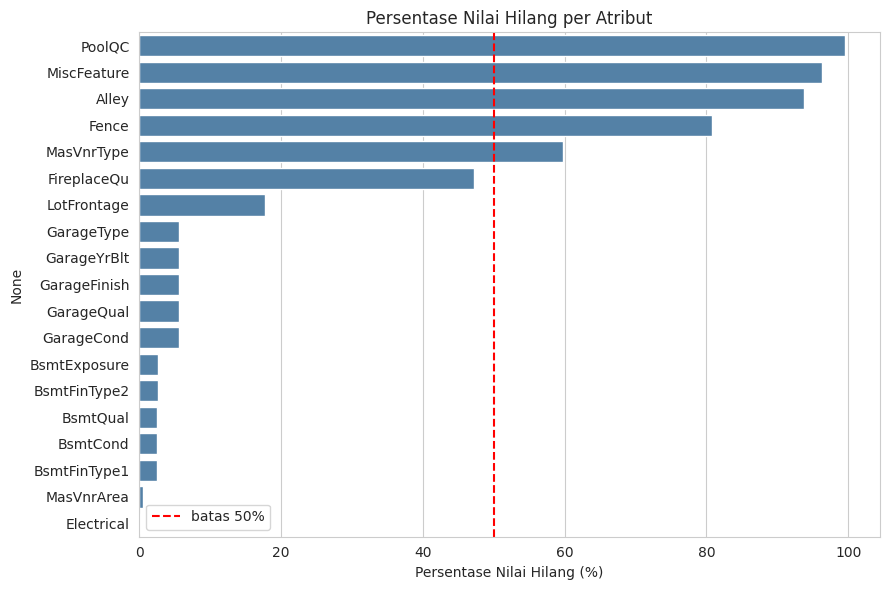

In [6]:
plt.figure(figsize=(9, 6))
sns.barplot(x=missing_table["persen_hilang"], y=missing_table.index, color="steelblue")
plt.axvline(50, color="red", linestyle="--", label="batas 50%")
plt.xlabel("Persentase Nilai Hilang (%)")
plt.title("Persentase Nilai Hilang per Atribut")
plt.legend()
plt.tight_layout()
plt.savefig("plots/01_missing_values.png")
plt.show()


Terlihat ada 5 kolom yang nilai hilangnya lebih dari 50%, yaitu `PoolQC`, `MiscFeature`, `Alley`, `Fence`, dan `MasVnrType`. Kolom-kolom ini sebaiknya dibuang karena terlalu banyak datanya yang kosong sehingga tidak banyak membantu proses analisis.

### 2.2 Hapus Kolom dengan Nilai Hilang > 50%

In [7]:
cols_to_drop = missing_table[missing_table["persen_hilang"] > 50].index.tolist()
print("Kolom yang dibuang:", cols_to_drop)

df = df.drop(columns=cols_to_drop)
print("Shape setelah kolom dibuang:", df.shape)


Kolom yang dibuang: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']
Shape setelah kolom dibuang: (1460, 76)


### 2.3 Tangani Nilai Hilang yang Tersisa
Untuk kolom numerik, nilai yang hilang diisi dengan **median**, karena median lebih tahan terhadap outlier dibanding rata-rata. Untuk kolom kategorik, nilai yang hilang diisi dengan **modus** (nilai yang paling sering muncul).

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include="object").columns

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Total nilai hilang setelah penanganan:", df.isnull().sum().sum())


Total nilai hilang setelah penanganan: 0


/tmp/ipykernel_91/2437032038.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


## 3. Deteksi dan Penanganan Outlier

Deteksi outlier dilakukan menggunakan **boxplot** pada beberapa atribut numerik yang penting, yaitu `SalePrice`, `GrLivArea`, `LotArea`, `TotalBsmtSF`, dan `1stFlrSF`.

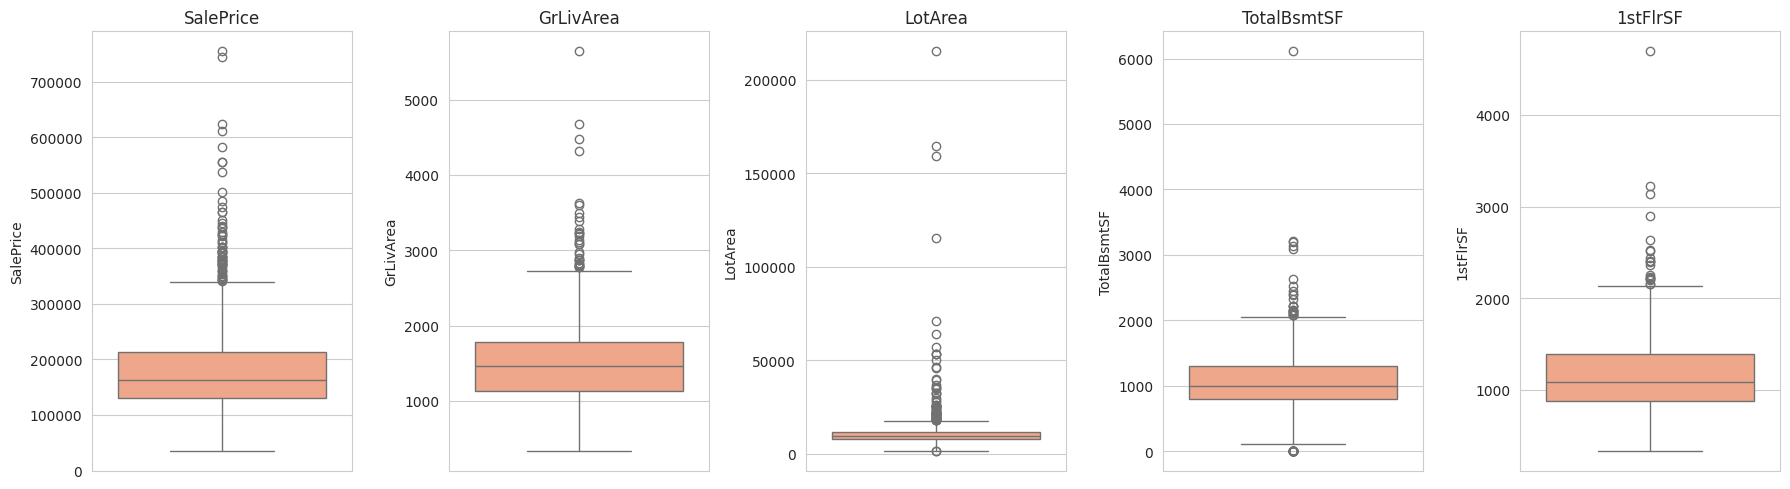

In [9]:
outlier_cols = ["SalePrice", "GrLivArea", "LotArea", "TotalBsmtSF", "1stFlrSF"]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightsalmon")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("plots/02_boxplot_before.png")
plt.show()


Outlier dihitung menggunakan metode **IQR (Interquartile Range)**: nilai di luar rentang `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` dianggap outlier.

In [10]:
def batas_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

for col in outlier_cols:
    lower, upper = batas_iqr(df[col])
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outlier} outlier (batas: {lower:.1f} - {upper:.1f})")


SalePrice: 61 outlier (batas: 3937.5 - 340037.5)
GrLivArea: 31 outlier (batas: 158.6 - 2747.6)
LotArea: 69 outlier (batas: 1481.5 - 17673.5)
TotalBsmtSF: 61 outlier (batas: 42.0 - 2052.0)
1stFlrSF: 20 outlier (batas: 118.1 - 2155.1)


**Keputusan penanganan outlier:** outlier tidak dihapus, melainkan **disesuaikan (capping/winsorizing)** ke batas bawah/atas IQR.

**Alasan:**
- Dataset hanya berisi 1460 baris, sehingga menghapus baris outlier akan mengurangi jumlah data secara signifikan.
- Rumah dengan ukuran atau harga yang ekstrem bukan berarti data salah input, melainkan tetap merupakan data yang valid (misalnya rumah mewah yang memang berukuran besar).
- Dengan capping, pengaruh nilai ekstrem terhadap model tetap berkurang tanpa kehilangan baris data.

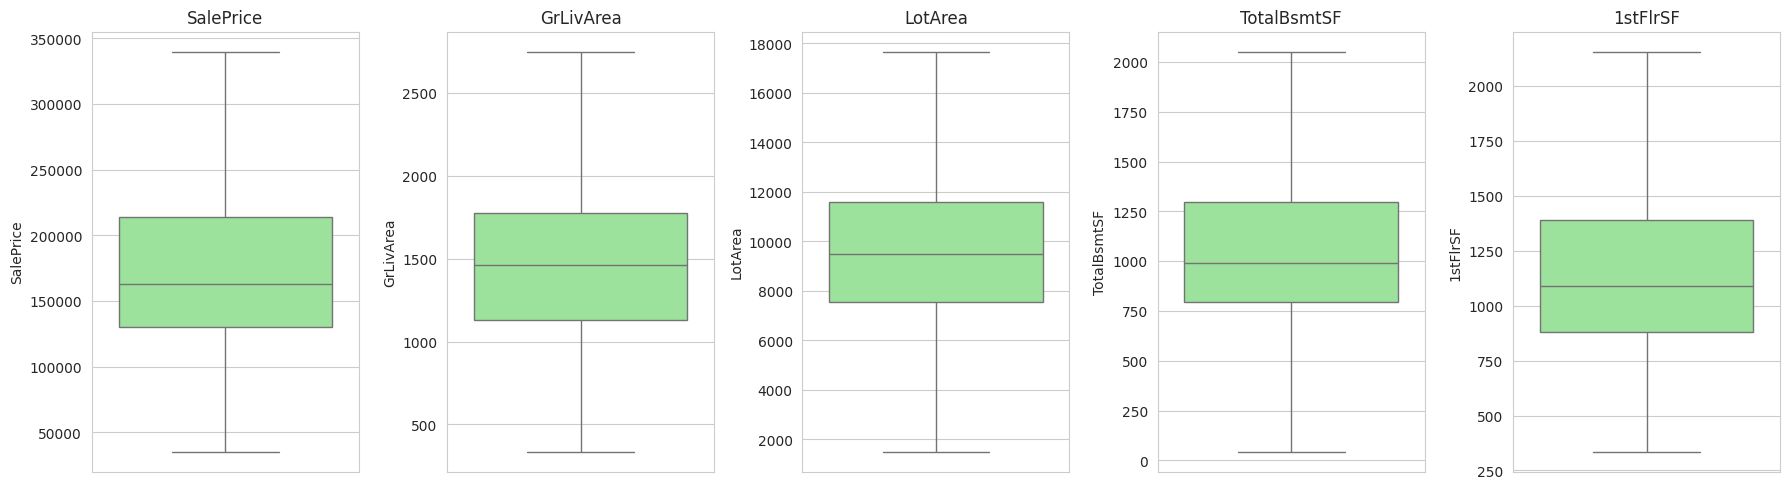

In [11]:
for col in outlier_cols:
    lower, upper = batas_iqr(df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightgreen")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("plots/03_boxplot_after.png")
plt.show()


## 4. Simpan Dataset Bersih

Dataset yang disimpan adalah dataset hasil pembersihan: kolom dengan nilai hilang >50% sudah dibuang, sisa nilai hilang sudah diisi (median/modus), dan outlier pada atribut numerik utama sudah ditangani (capping). Data masih dalam skala dan format aslinya (belum distandarisasi/di-encode).

In [12]:
df.to_csv("house_prices_cleaned.csv", index=False)

print("Dataset awal :", (1460, 81))
print("Dataset bersih:", df.shape)
print("File disimpan: house_prices_cleaned.csv")


Dataset awal : (1460, 81)
Dataset bersih: (1460, 76)
File disimpan: house_prices_cleaned.csv


## 5. Kesimpulan

1. Dari 81 kolom awal, 5 kolom dibuang karena nilai hilangnya lebih dari 50%.
2. Nilai hilang yang tersisa berhasil ditangani menggunakan median (numerik) dan modus (kategorik) sehingga tidak ada lagi nilai kosong.
3. Outlier pada atribut numerik penting ditangani dengan metode capping (IQR) agar data ekstrem tidak terlalu mendominasi tanpa mengurangi jumlah baris data.
4. Dataset akhir hasil pembersihan berukuran 1460 baris dan 76 kolom, sudah siap untuk tahap transformasi (normalisasi/encoding) pada praktikum berikutnya.